In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn import preprocessing
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('drugs (1).csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
df['Proveedor'] = df['Drug'].replace({
    'drugA': 'nacional',
    'drugB': 'nacional',
    'drugC': 'nacional',
    'drugX': 'extranjero',
    'drugY': 'extranjero'
})

df[['Drug', 'Proveedor']].head()

,Drug,Proveedor
0,drugY,extranjero
1,drugC,nacional
2,drugC,nacional
3,drugX,extranjero
4,drugY,extranjero


In [4]:
feature_cols = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
X = df[feature_cols].values
y = df['Proveedor']

In [26]:
Cod_Sex = preprocessing.LabelEncoder()
Cod_BP = preprocessing.LabelEncoder()
Cod_Chol = preprocessing.LabelEncoder()

df['Sex'] = Cod_Sex.fit_transform(df['Sex'])
df['BP'] = Cod_BP.fit_transform(df['BP'])
df['Cholesterol'] = Cod_Chol.fit_transform(df['Cholesterol'])

feature_cols = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
X = df[feature_cols]
y =df['Proveedor']

In [28]:
Cod_y = preprocessing.LabelEncoder()
y = Cod_y.fit_transform(y)

In [30]:
Cod_y.classes_

array(['extranjero', 'nacional'], dtype=object)

In [32]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 1)

# SOLVER SAG

In [34]:
model = LogisticRegression(solver='sag')
clf = model.fit(X_train, y_train)

In [38]:
y_pred = model.predict(x_test)

print('Intercepto (beta 0):', clf.intercept_)
print('Pesos de cada variable (betas):', clf.coef_)

Intercepto (beta 0): [0.31647097]
Pesos de cada variable (betas): [[ 0.03721892  0.16108448 -1.02743785 -0.19933688 -0.16040884]]


In [42]:
score = model.score(x_test, y_test)
print('Score de precisión:', score)

Score de precisión: 0.9


In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94        30
           1       1.00      0.60      0.75        10

    accuracy                           0.90        40
   macro avg       0.94      0.80      0.84        40
weighted avg       0.91      0.90      0.89        40



# SOLVER NEWTON-CG

In [48]:
model = LogisticRegression(solver='newton-cg')
clf = model.fit(X_train, y_train)

y_pred = model.predict(x_test)

print('Intercepto (beta 0):', clf.intercept_)
print('Pesos de cada variable (betas):', clf.coef_)
print('-------------------------------------------------')
print('Score de precisión:', model.score(x_test, y_test))
print(classification_report(y_test, y_pred))

Intercepto (beta 0): [11.15252429]
Pesos de cada variable (betas): [[-0.00660829 -0.14830595 -3.33610522 -2.07245809 -0.63787728]]
-------------------------------------------------
Score de precisión: 0.975
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.90      0.95        10

    accuracy                           0.97        40
   macro avg       0.98      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40



# SOLVER LIBLINEAR

In [55]:
model = LogisticRegression(solver='liblinear')
clf = model.fit(X_train, y_train)

y_pred = model.predict(x_test)

print('Intercepto (beta 0):', clf.intercept_)
print('Pesos de cada variable (betas):', clf.coef_)
print('-------------------------------------------------')
print('Score de precisión:', model.score(x_test, y_test))
print(classification_report(y_test, y_pred))

Intercepto (beta 0): [3.34051275]
Pesos de cada variable (betas): [[ 0.02834219  0.26053256 -2.06969328 -1.09570978 -0.27510142]]
-------------------------------------------------
Score de precisión: 0.975
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.90      0.95        10

    accuracy                           0.97        40
   macro avg       0.98      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40



# SOLVER SAGA

In [57]:
modelv= LogisticRegression(solver='saga')
clf = model.fit(X_train, y_train)

y_pred = model.predict(x_test)

print('Intercepto (beta 0):', clf.intercept_)
print('Pesos de cada variable (betas):', clf.coef_)
print('-------------------------------------------------')
print('Score de precisión:', model.score(x_test, y_test))
print(classification_report(y_test, y_pred))

Intercepto (beta 0): [3.34051275]
Pesos de cada variable (betas): [[ 0.02834219  0.26053256 -2.06969328 -1.09570978 -0.27510142]]
-------------------------------------------------
Score de precisión: 0.975
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.90      0.95        10

    accuracy                           0.97        40
   macro avg       0.98      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40



# SOLVER LBFGS

In [73]:
model = LogisticRegression(solver='lbfgs')
clf = model.fit(X_train, y_train)

y_pred = model.predict(x_test)

print('Intercepto (beta 0):', clf.intercept_)
print('Pesos de cada variable (betas):', clf.coef_)
print('-------------------------------------------------')
print('Score de precisión:', model.score(x_test, y_test))
print(classification_report(y_test, y_pred))

Intercepto (beta 0): [11.16791614]
Pesos de cada variable (betas): [[-0.00667297 -0.14894912 -3.33863745 -2.07461152 -0.63862512]]
-------------------------------------------------
Score de precisión: 0.975
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.90      0.95        10

    accuracy                           0.97        40
   macro avg       0.98      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40



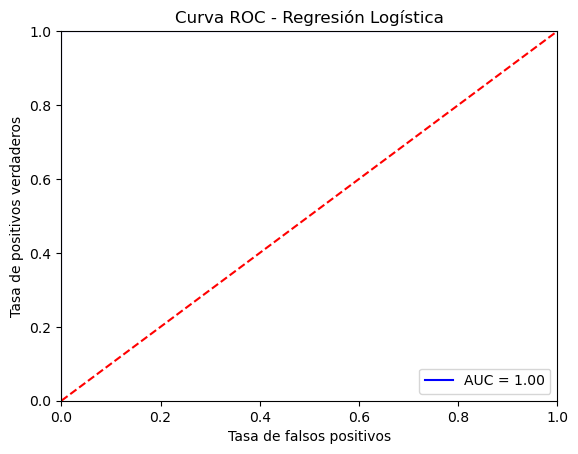

In [85]:
model = LogisticRegression(solver='newton-cg')
clf = model.fit(X_train, y_train)
y_pred = model.predict(x_test)

y_pred_probs = clf.predict_proba(x_test)[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_probs)
roc_auc = metrics.auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label= 'AUC = %0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1], [0,1], 'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('Tasa de positivos verdaderos')
plt.xlabel('Tasa de falsos positivos')
plt.title('Curva ROC - Regresión Logística')
plt.show()

Se aprobaron distintos métodos de optimización para la regresión logística:SAG, Newton-CG, liblinear, SAGA Y LBFGS. El mejor modelo se eligió con basae en la precisión obtenida en el conjunto de prueba, el reporte de clasificación y la curva ROC. El solver recomendado para este casao el que mostró el mejot equilibrio entrea accuracy, precision, recall y f1-score.

Y para este casó fueron dos, tanto el lbfgs y el newton-cg mostraron una eficacia de 1.0, por lo que cualquiera de los dos sería participe para este trabajo.